# Tool Calling
This notebook covers basics of agentic tool calling

In [ ]:
from langchain_groq.chat_models import ChatGroq
from langchain_core.tools import tool
from dotenv import load_dotenv
from pydantic import SecretStr
import os

In [194]:
load_dotenv()
api_key = os.getenv("GROQ_API_KEY")
if api_key:
    GROQ_API_KEY = SecretStr(api_key)

In [195]:
llm = ChatGroq(model="llama-3.3-70b-versatile", api_key=GROQ_API_KEY)

**Business take**

Imagine we are building LLM-based system for weather forecasts, so we need our LLM to be able to obtain knowledge about current weather

In [218]:
llm.invoke("What's the weather like in Minsk right now?").content

'I\'m a large language model, I don\'t have real-time access to current weather conditions. But I can suggest some ways for you to find out the current weather in Minsk:\n\n1. Check online weather websites: You can visit websites like AccuWeather, Weather.com, or the Belarusian national weather service to get the current weather conditions in Minsk.\n2. Use a weather app: You can download a weather app on your smartphone, such as Dark Sky or Weather Underground, which can provide you with real-time weather updates for Minsk.\n3. Search for "Minsk weather" on a search engine: You can type "Minsk weather" or "current weather in Minsk" on a search engine like Google, and it will show you the current weather conditions in Minsk.\n\nPlease note that I\'m a large language model, my knowledge cutoff is limited, and I may not have the most up-to-date information. However, I can provide you with general information about Minsk\'s climate.\n\nMinsk, the capital city of Belarus, has a humid conti

The problem is that having been trained once, LLMs can not obtain real-time information. For instance this specific model was last trained in 2023 and will not be able to answer questions on events after 2023.

What can help us is so called **tools**. In general definitions a **tool** is native python function that can do something out of models scope. For instance it can call API, do calculations call another LLM and almost everything we can only find use-case for.

In terms of `LangChain` a **tool** is any Python function wrapped with `@tool` decorator as in the example below

In [ ]:
@tool()
def get_weather(location:str):
    """
    Get current weaather for the specified location
    
    Args:
        location (str): location to fetch weather for
    """
    return f"It's sunny in {location} right now"

**Tool breakdown**:
1. Every function wrapped with `@tool` will be considered to be an LLM tool
2. `@tool` can take some useful optional arguments:
    - `description: str | None` - additionally explains what the tool is designed for
    - `return_direct: bool = False` - return tool response directly to chat or not
    - `args_schema: ArgsSchema | None = None` - sctructured schema for inputs validation
    - `parse_docstring: bool = False` - get input variables from docstring or not
3. The tool strictly expects a docstring, no docstring = fail. It does not neccessarily require to describe each arg but LLM reads from docstring to understand what to use the tool for and how to use it
4. Tools must return strings.


In [197]:
tools = [get_weather]

In [ ]:
llm_with_tools = llm.bind_tools(tools)

In [224]:
response = llm_with_tools.invoke("What's the weather like right now in Minsk?")

In [225]:
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ykyqmx4hh', 'function': {'arguments': '{"location":"Minsk"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 229, 'total_tokens': 244, 'completion_time': 0.030107457, 'completion_tokens_details': None, 'prompt_time': 0.011444394, 'prompt_tokens_details': None, 'queue_time': 0.091335033, 'total_time': 0.041551851}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_c06d5113ec', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c27b0-0e62-7be2-b6ef-c42a3793a74b-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Minsk'}, 'id': 'ykyqmx4hh', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 229, 'output_tokens': 15, 'total_tokens': 244})

Here in response we see **tool_calls** in **additional_kwargs** which is a list of tools the model decided to call and some metadata neccessary for tool call definition.

- `id` - simply a tool call id
- `function` - a dictionary of tool call data:
    - `arguments`: a dictionary of inputs to the tool
    - `name`: a name of the called tool
- `type`: a type of called tool

In [226]:
response.content

''

But despite the fact that model decided to call a tool and actually called it, the response content is empty, why?

Well actually this happens because we expect the response from the LLM, not from tool. The tool has been called, executed but did not return it's response back to the llm. Or even better to say that LLM did not gave back a response with tool context as it wasn't called one more time. Therefore the response content is empty.

Typical flow should be as follows:

LLM -> tool_call -> tool_execution -> LLM


In [227]:
response.tool_calls

[{'name': 'get_weather',
  'args': {'location': 'Minsk'},
  'id': 'ykyqmx4hh',
  'type': 'tool_call'}]

To perform correct LLM -> tools -> LLM cycle we'll utilize `LangGraph`'s capabilities, `ToolNode` in particular.

In [205]:
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode

In [206]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

system_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an intelligent AI assistant designed to answer user queries. In your arsenal you have tools. Call them if neccessary. Tools are the following:
- get_weather: use when user asks for weather in their location"""),
    MessagesPlaceholder(variable_name="messages")
])
chain = system_prompt | llm_with_tools

For simplicity define only `messages` for `ChatState`

In [207]:
from typing import TypedDict, Annotated
import operator

class ChatState(TypedDict):
    messages: Annotated[list, operator.add]

In [208]:
def llm_call(state:ChatState):
    messages = state["messages"]
    llm_response = chain.invoke({"messages": messages})
    return {"messages": [llm_response]}

So the magic starts to happen here. As we've already seen `AIMessage` object contains `tool_calls` key. So we check if the last of LLM generated messages contained any tool calls. It's important to admit that it generated an empty response (content field is empty I mean) like one seen above.

So in case the LLM called a tool we will route to the `tools` node which is responsible for tool execution.

Otherwise LLM decided not to call any tools and we can simply yield LLM response.

In [209]:
def tool_router(state:ChatState):
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return "END"

That's how we define a magic `ToolNode`. It will seamlessly execute a tool itself. Then the flow is as follows:

1. As tools are obliged to return strings, `ToolNode` wraps a tool response with `ToolMessage` so that the LLM would understand that the message came from a tool.
2. Then the `ToolMessage` is added to a list of messages and this can be a little tricky, there are some conditions:
    - The state MUST have `messages` field as `ToolNode` automatically updates this field, otherwise the whole graph will fail.
    - In order to add the message to list of messages (not overwrite) we need to use reducers, like `messages: Annotated[list, operator.add]`
3. Then LLM call node is triggered again and now it has a response from the tool, so it can generate a response.

In [210]:
tool_node = ToolNode(tools)

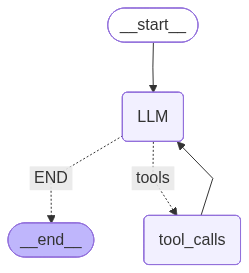

In [211]:
graph = StateGraph(ChatState)
graph.add_node("LLM", llm_call)
graph.add_node("tool_calls", tool_node)
graph.add_edge(START, "LLM")
graph.add_conditional_edges(
    source="LLM",
    path=tool_router,
    path_map={
        "tools":"tool_calls",
        "END": END
    }
)
graph.add_edge("tool_calls", "LLM")
app = graph.compile()
app


In [212]:
from langchain_core.messages import HumanMessage
initial_state = {
    "messages": [HumanMessage(content="What's the weaather like today in Minsk?")]
}

In [213]:
response = app.invoke(initial_state)

In [214]:
response

{'messages': [HumanMessage(content="What's the weaather like today in Minsk?", additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'g170sjad5', 'function': {'arguments': '{"location":"Minsk"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 274, 'total_tokens': 289, 'completion_time': 0.039156656, 'completion_tokens_details': None, 'prompt_time': 0.013570038, 'prompt_tokens_details': None, 'queue_time': 0.156810435, 'total_time': 0.052726694}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c27ad-33fe-79a2-85f5-b5b5d4d0fabb-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Minsk'}, 'id': 'g170sjad5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 274, 'output_to

In [215]:
for chunk in app.stream(initial_state, stream_mode="values"):
    if chunk["messages"]:
        chunk["messages"][-1].pretty_print()

================================ Human Message =================================

What's the weaather like today in Minsk?
================================== Ai Message ==================================
Tool Calls:
  get_weather (ybk5z75k8)
 Call ID: ybk5z75k8
  Args:
    location: Minsk
================================= Tool Message =================================
Name: get_weather

It's sunny in Minsk right now
================================== Ai Message ==================================

The current weather in Minsk is sunny.
